# Analysis of Kyle’s Lambda on the Market Impact

## Part A – Kyle’s Lambda
Kyle (1985) proposed that for short intervals (e.g., 5 seconds), order book thickness can be approximated by:
$$
\lambda = \frac{\Delta P_t}{\text{OrderFlow}_t}
$$

where:  
$\Delta P_t$ = price change in interval $t$  
$\text{OrderFlow}_t$ = trade volume × sign of the price change (positive for increases, negative for decreases).

**Interpretation:**  
Smaller $\lambda$ = thicker order book (price moves little for a given trade volume).  
Larger $\lambda$ = thinner order book (price moves more for the same volume).

### Hypothesis

#### 1) λ differs between Brent and WTI
- Eventhough Brent and WTI are linked through arbitrage, differences in market structure and purpose differentiates between the two benchmarks. Brent serves as the global pricing benchmark but trades on a relatively thinner order book, while WTI futures experience more speculation and hedging activity on the CME. These liquidity differences should be reflected in Kyle’s $\lambda$, leading me to expect significantly different $\lambda$ estimates for Brent and WTI.
 
#### 2) $\lambda$ varies intraday and is expected to be smaller during core market hours
- Although futures trade nearly 24 hours a day, the majority of volume and liquidity is concentrated during U.S. and European trading hours. Higher trading activity during this window implies deeper order books and tighter spreads, so individual trades exert less price impact. Therefore, I hypothesize that Kyle’s $\lambda$ will be smaller during market hours.

#### 3) λ decreases near expiry and increases in farther-out contracts
- As futures contracts approach expiry, arbitrage guarantees a convergence to the spot market price.
- In addition, as contracts approach expiry speculators and hedgers will offset their positions, increasing liquidity.
- Consequently, trades exert less influence on prices, leading to smaller $\lambda$ near expiry.
- By contrast, farther-out contracts trade with lower volumes and thinner order books, so $\lambda$ is expected to be larger.

## Part B – Data Preparation
You are provided with 5-minute interval data (prices and volumes) for November 2025 WTI and Brent crude oil futures (30 days of around-the-clock trading: opens Sunday 5 pm, closes Friday 4 pm)

In [ ]:
# install & import libraries
%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# load the data files
# CBZ25 = Brent crude oil futures (December 2025)
# CLV25 = WTI crude oil futures (October 2025)

# WTI (West Texas Intermediate) = U.S.
# Brent = Europe, Africa, and the Middle East 

brent_data = pd.read_csv('data/cbz25_intraday-5min_historical-data-09-16-2025.csv')
wti_data = pd.read_csv('data/clv25_intraday-5min_historical-data-09-16-2025.csv')

# checking data structure
print("Brent:")
print(brent_data.head())
print("\nWTI:")
print(wti_data.head())

Brent:
               Time   Open   High    Low   Last  Change    %Chg  Volume
0  2025-08-17 17:00  64.87  65.04  64.51  64.54   -0.49  -0.75%     185
1  2025-08-17 17:05  64.55  64.59  64.53  64.58    0.04   0.06%     117
2  2025-08-17 17:10  64.56  64.63  64.54  64.63    0.05   0.08%      61
3  2025-08-17 17:15  64.65  64.71  64.65  64.67    0.04   0.06%      64
4  2025-08-17 17:20  64.68  64.68  64.65  64.65   -0.02  -0.03%      15

WTI:
               Time   Open   High    Low   Last  Change    %Chg  Volume
0  2025-08-17 17:00  62.19  62.19  61.65  61.67   -0.62  -1.00%    1150
1  2025-08-17 17:05  61.68  61.76  61.67  61.73    0.06   0.10%     248
2  2025-08-17 17:10  61.73  61.80  61.71  61.78    0.05   0.08%     171
3  2025-08-17 17:15  61.77  61.87  61.75  61.83    0.05   0.08%     203
4  2025-08-17 17:20  61.83  61.84  61.78  61.83    0.00   0.00%     113


In [3]:
# subset data for only what is necessary
brent_data = brent_data[["Time", "Change", "Volume"]]
wti_data = wti_data[["Time", "Change", "Volume"]]

# convert Time column to datetime
brent_data['Time'] = pd.to_datetime(brent_data['Time'])
wti_data['Time'] = pd.to_datetime(wti_data['Time'])

# add benchmark column for Brent and WTI
brent_data['Benchmark'] = 'Brent'
wti_data['Benchmark'] = 'WTI'

#### 1.1 Aggregate 5-minute trading volumes into hourly totals, then compute the average hourly volume for each clock hour across all days.

In [4]:
# compute hour column and date column for aggregation at the hour level
brent_data['Hour'] = brent_data['Time'].dt.hour
brent_data['Date'] = brent_data['Time'].dt.date
wti_data['Hour'] = wti_data['Time'].dt.hour
wti_data['Date'] = wti_data['Time'].dt.date

In [5]:
print(wti_data.head())

                 Time  Change  Volume Benchmark  Hour        Date
0 2025-08-17 17:00:00   -0.62    1150       WTI    17  2025-08-17
1 2025-08-17 17:05:00    0.06     248       WTI    17  2025-08-17
2 2025-08-17 17:10:00    0.05     171       WTI    17  2025-08-17
3 2025-08-17 17:15:00    0.05     203       WTI    17  2025-08-17
4 2025-08-17 17:20:00    0.00     113       WTI    17  2025-08-17


In [6]:
# check date range; f lets me run formulas inside print statements
print(f"Date range (Brent): {brent_data['Time'].min()} to {brent_data['Time'].max()}")
print(f"Date range (WTI): {wti_data['Time'].min()} to {wti_data['Time'].max()}")

# check if any values are missing
print(f"\nMissing values (Brent): {brent_data.isna().values.sum()}")
print(f"Missing values (WTI): {wti_data.isna().values.sum()}")

# check how many rows and columns
print(f"\n(rows, columns): {brent_data.shape}")
print(f"(rows, columns): {wti_data.shape}\n")

# how many rows we should have after aggregating
print(f"After aggregation: {brent_data.shape[0]+wti_data.shape[0]}")

Date range (Brent): 2025-08-17 17:00:00 to 2025-09-12 16:55:00
Date range (WTI): 2025-08-17 17:00:00 to 2025-09-12 15:55:00

Missing values (Brent): 0
Missing values (WTI): 0

(rows, columns): (5106, 6)
(rows, columns): (5487, 6)

After aggregation: 10593


In [7]:
# concatenate datasets before calculation to save time
# ignore_index = TRUE will assign unique indexes in the aggregated dataframe
all_data = pd.concat([brent_data, wti_data], ignore_index=True)

print(f"(rows, columns): {all_data.shape}")
print(all_data.head(10))

(rows, columns): (10593, 6)
                 Time  Change  Volume Benchmark  Hour        Date
0 2025-08-17 17:00:00   -0.49     185     Brent    17  2025-08-17
1 2025-08-17 17:05:00    0.04     117     Brent    17  2025-08-17
2 2025-08-17 17:10:00    0.05      61     Brent    17  2025-08-17
3 2025-08-17 17:15:00    0.04      64     Brent    17  2025-08-17
4 2025-08-17 17:20:00   -0.02      15     Brent    17  2025-08-17
5 2025-08-17 17:25:00    0.10      66     Brent    17  2025-08-17
6 2025-08-17 17:30:00   -0.09       9     Brent    17  2025-08-17
7 2025-08-17 17:35:00    0.00       1     Brent    17  2025-08-17
8 2025-08-17 17:40:00   -0.02      13     Brent    17  2025-08-17
9 2025-08-17 17:45:00    0.00       3     Brent    17  2025-08-17


In [8]:
# aggregate 5-minute volumes into daily hourly sums
# we use .reset_index() to keep volume as its own column and drop Brent/WTI down 
volume_hour = all_data.groupby(['Benchmark', 'Date', 'Hour'])['Volume'].sum().reset_index()

# calculate average hourly volume for each clock hour across all days
avg_volume_hour = volume_hour.groupby(['Benchmark', 'Hour'])['Volume'].mean().reset_index()

#### 1.2 Plot average hourly volume over a 24-hour cycle. Compare the pattern with your hypotheses. Adjust if necessary.

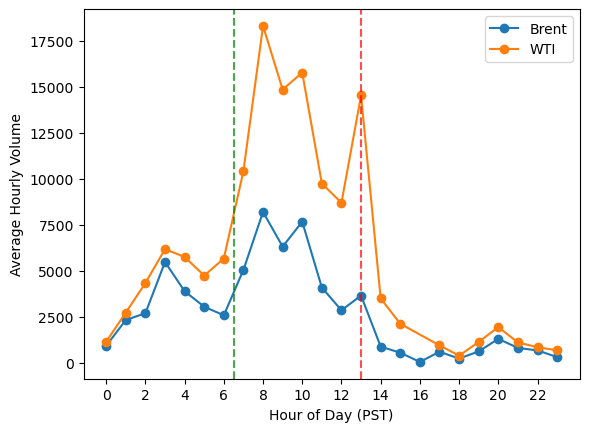

In [9]:
# plot
# after inspection, the timezone from the output is likely in PST from Prof. Vercammen's output settings
# we move forward assuming time in PST, where market opens between 6:30am-1:00pm

plt.figure()

# create Brent and WTI dataframes for plotting
brent_hourly = avg_volume_hour[avg_volume_hour['Benchmark'] == 'Brent']
wti_hourly = avg_volume_hour[avg_volume_hour['Benchmark'] == 'WTI']

# plot Brent and WTI
# hour on x, volume on y
plt.plot(brent_hourly['Hour'], brent_hourly['Volume'], label='Brent',  marker='o')
plt.plot(wti_hourly['Hour'], wti_hourly['Volume'], label='WTI',  marker='o')
plt.xlabel('Hour of Day (PST)')
plt.ylabel('Average Hourly Volume')
plt.legend()
plt.xticks(range(0, 24, 2))

# reference lines for market open and close in PST
plt.axvline(x=6.5, color='green', linestyle='--', alpha=0.7, label='US Market Open')
plt.axvline(x=13, color='red', linestyle='--', alpha=0.7, label='US Market Close')

plt.show()

Note: Visually, hypothesis 2 seems promising. Volume is much higher during trading hours. However, we cannot draw formal conclusions as price chage is not included in this graph.

#### 1.3 Next, calculate and plot average daily trading volumes. Identify any days with unusually high volumes. If you find spikes, investigate possible causes using news sources and report your findings.

  Benchmark        Date  Volume
0     Brent  2025-08-17    4755
1     Brent  2025-08-18   40186
2     Brent  2025-08-19   36238
3     Brent  2025-08-20   42300
4     Brent  2025-08-21   38536


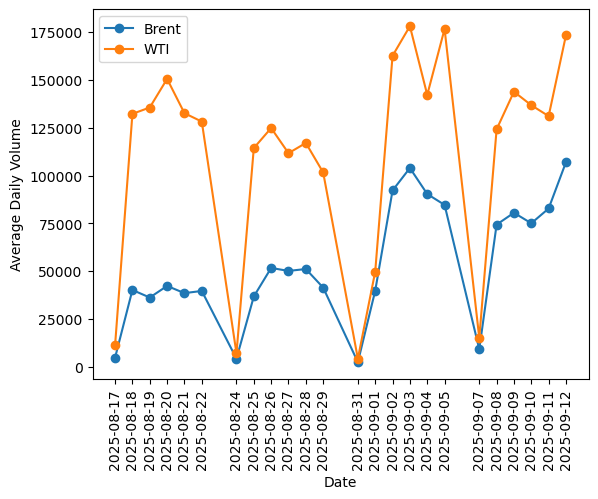

In [10]:
# calculate daily trading volumes
daily_volumes = all_data.groupby(['Benchmark', 'Date'])['Volume'].sum().reset_index()
print(daily_volumes.head())

# create Brent and WTI dataframes for plotting
brent_daily = daily_volumes[daily_volumes['Benchmark'] == 'Brent']
wti_daily = daily_volumes[daily_volumes['Benchmark'] == 'WTI']

# plot Brent and WTI
# hour on x, volume on y
plt.plot(brent_daily['Date'], brent_daily['Volume'], label='Brent',  marker='o')
plt.plot(wti_daily['Date'], wti_daily['Volume'], label='WTI',  marker='o')
plt.xlabel('Date')
plt.ylabel('Average Daily Volume')
plt.legend()
plt.xticks(daily_volumes["Date"].unique(), rotation=90)

plt.show()

The volumes separating into chunks make sense as futures market do not trade on Saturdays. The low volume on the first day makes sense as well, since the market opens at 5pm PST on Sundays. Interestingly, even though Fridays end early at 5pm PST, we see similar volumes compared to midweek; a likely explanation is that people are trading primarily during work hours. 

There appears to be a spike on September 12th. Online sources show that it's due to a decrease in US crude oil inventories, specifically by 9.3 million barrels during the week ending September 12 (Geiger, 2025). It is possible that this decrease in inventories exceeded analyst projections, causing prices to soar.

https://oilprice.com/Energy/Crude-Oil/US-Crude-Oil-Inventories-Plummet-Pushing-Prices-Higher.html

#### 2.1 Add a new column 𝑄_t = volume × sign of ΔP for each 5-minute interval.

In [11]:
# Order Flow: Q_t = volume × sign(delta P)
# delta P is last trade - this trade
analysis_data = all_data.copy()

# change = delta_P; change also has a sign by default
analysis_data = analysis_data.rename(columns={"Change": "Delta_P"})

# extract sign from delta_P
analysis_data['Sign_Delta_P'] = np.sign(analysis_data['Delta_P'])

# order flow: Q_t = Volume × Sign(ΔP)
analysis_data['Order_Flow'] = analysis_data['Volume'] * analysis_data['Sign_Delta_P']

analysis_data.head()

,Time,Delta_P,Volume,Benchmark,Hour,Date,Sign_Delta_P,Order_Flow
0,2025-08-17 17:00:00,-0.49,185,Brent,17,2025-08-17,-1.0,-185.0
1,2025-08-17 17:05:00,0.04,117,Brent,17,2025-08-17,1.0,117.0
2,2025-08-17 17:10:00,0.05,61,Brent,17,2025-08-17,1.0,61.0
3,2025-08-17 17:15:00,0.04,64,Brent,17,2025-08-17,1.0,64.0
4,2025-08-17 17:20:00,-0.02,15,Brent,17,2025-08-17,-1.0,-15.0


In [12]:
# check for zero price changes (where sign is 0)
zero_changes = analysis_data[analysis_data['Sign_Delta_P'] == 0]
print(f"\nObservations with delta_P = 0: {len(zero_changes)}")

# this is an issue, since Delta_P being 0 doesn't mean no volume ocurred. The volume is still meaningful.
# we remove the 0s and take the sign of the last 5 minutes
analysis_data["Sign_Delta_P"] = (
    analysis_data["Sign_Delta_P"].replace(0, np.nan).ffill())

print(analysis_data.head(10))
zero_changes = analysis_data[analysis_data['Sign_Delta_P'] == 0]
print(f"\nObservations with delta_P = 0 now: {len(zero_changes)}")

# recalculate order flow: Q_t = Volume × Sign(ΔP)
analysis_data['Order_Flow'] = analysis_data['Volume'] * analysis_data['Sign_Delta_P']


Observations with delta_P = 0: 1298
                 Time  Delta_P  Volume Benchmark  Hour        Date  \
0 2025-08-17 17:00:00    -0.49     185     Brent    17  2025-08-17   
1 2025-08-17 17:05:00     0.04     117     Brent    17  2025-08-17   
2 2025-08-17 17:10:00     0.05      61     Brent    17  2025-08-17   
3 2025-08-17 17:15:00     0.04      64     Brent    17  2025-08-17   
4 2025-08-17 17:20:00    -0.02      15     Brent    17  2025-08-17   
5 2025-08-17 17:25:00     0.10      66     Brent    17  2025-08-17   
6 2025-08-17 17:30:00    -0.09       9     Brent    17  2025-08-17   
7 2025-08-17 17:35:00     0.00       1     Brent    17  2025-08-17   
8 2025-08-17 17:40:00    -0.02      13     Brent    17  2025-08-17   
9 2025-08-17 17:45:00     0.00       3     Brent    17  2025-08-17   

   Sign_Delta_P  Order_Flow  
0          -1.0      -185.0  
1           1.0       117.0  
2           1.0        61.0  
3           1.0        64.0  
4          -1.0       -15.0  
5           

## Part C – Estimation of Kyle’s Lambda

#### 3.1 Baseline Model 
o Estimate: $\Delta P_t = \lambda Q_t + e_t$  
o Report $\lambda$ and describe what it measures.

In [13]:
# regression using delta_P as the dependent variable and Q_t (order flow) as the independent variable
# lambda is the beta1 from the regression output

for benchmark in ["WTI", "Brent"]:
    subset = analysis_data[analysis_data["Benchmark"] == benchmark]
    
    X = sm.add_constant(subset["Order_Flow"])
    y = subset["Delta_P"]

    model = sm.OLS(y, X).fit()
    print(f"\n{benchmark} Output")
    print(model.summary())


WTI Output
                            OLS Regression Results                            
Dep. Variable:                Delta_P   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     5728.
Date:                Sat, 27 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:20:01   Log-Likelihood:                 10064.
No. Observations:                5487   AIC:                        -2.012e+04
Df Residuals:                    5485   BIC:                        -2.011e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.001      0.

WTI lambda = 4.449e-05  
Brent lambda = 7.893e-05

$\lambda$ represents how much price changes for a one unit increase of order_flow.  
Brent is nearly double of WTI; this makes sense as from the figure earlier, descriptively volume is much larger for WTI than Brent.

#### 3.2 Seasonal Control 
o Re-estimate the model adding hourly or daily controls (i.e., dummies) to account for systematic variation in liquidity.  
o Compare $\lambda$ estimates with and without these controls - has $\lambda$ changed materially?  

In [14]:
# hourly dummies
for benchmark in ["WTI", "Brent"]:
    subset = analysis_data[analysis_data["Benchmark"] == benchmark].copy()
    model = smf.ols("Delta_P ~ Order_Flow + C(Hour)", data=subset).fit()

    print(f"\nResults for {benchmark}:")
    print(model.summary())


Results for WTI:
                            OLS Regression Results                            
Dep. Variable:                Delta_P   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     250.8
Date:                Sat, 27 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:20:01   Log-Likelihood:                 10080.
No. Observations:                5487   AIC:                        -2.011e+04
Df Residuals:                    5463   BIC:                        -1.995e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0026    

In [15]:
# days of the week dummies
analysis_data['DayOfWeek'] = analysis_data['Time'].dt.dayofweek

for benchmark in ["WTI", "Brent"]:
    subset = analysis_data[analysis_data["Benchmark"] == benchmark].copy()
    model = smf.ols("Delta_P ~ Order_Flow + C(DayOfWeek)", data=subset).fit()

    print(f"\nResults for {benchmark}:")
    print(model.summary())


Results for WTI:
                            OLS Regression Results                            
Dep. Variable:                Delta_P   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     954.8
Date:                Sat, 27 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:20:02   Log-Likelihood:                 10066.
No. Observations:                5487   AIC:                        -2.012e+04
Df Residuals:                    5480   BIC:                        -2.007e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           

#### 3.3 Hypothesis Testing 
o For each of your three hypotheses, subset the data as needed (e.g., WTI vs. Brent, calm vs. news days).  
o Estimate $\lambda$ for each subset and compare magnitudes.  
o State whether differences align with your expectations. Formal statistical testing is optional. 

#### Hypothesis

#### 1) $\lambda$ differs between Brent and WTI
- Eventhough Brent and WTI are linked through arbitrage, differences in market structure and purpose differentiates between the two benchmarks. Brent serves as the global pricing benchmark but trades on a relatively thinner order book, while WTI futures experience more speculation and hedging activity on the CME. These liquidity differences should be reflected in Kyle’s $\lambda$, leading me to expect significantly different $\lambda$ estimates for Brent and WTI.
 
#### 2) $\lambda$ varies intraday and is expected to be smaller during core market hours
- Although futures trade nearly 24 hours a day, the majority of volume and liquidity is concentrated during U.S. and European trading hours. Higher trading activity during this window implies deeper order books and tighter spreads, so individual trades exert less price impact. Therefore, I hypothesize that Kyle’s $\lambda$ will be smaller during market hours.

#### 3) $\lambda$ decreases near expiry and increases in farther-out contracts
- As futures contracts approach expiry, arbitrage guarantees a convergence to the spot market price.
- In addition, as contracts approach expiry speculators and hedgers will offset their positions, increasing liquidity.
- Consequently, trades exert less influence on prices, leading to smaller $\lambda$ near expiry.
- By contrast, farther-out contracts trade with lower volumes and thinner order books, so $\lambda$ is expected to be larger.

In [16]:
# 1) λ differs between Brent and WTI
model_diff = smf.ols("Delta_P ~ Order_Flow * C(Benchmark)", data=analysis_data).fit(cov_type='HC1')
print(model_diff.summary())

                            OLS Regression Results                            
Dep. Variable:                Delta_P   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     350.8
Date:                Sat, 27 Sep 2025   Prob (F-statistic):          3.31e-217
Time:                        02:20:02   Log-Likelihood:                 19536.
No. Observations:               10593   AIC:                        -3.906e+04
Df Residuals:                   10589   BIC:                        -3.903e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

#### Hypothesis 1 Interpretation
To test if Brent and WTI benchmarks have significantly different $\lambda$s, I estimated Delta_P as a function of order flow, benchmark, and their interaction term. I used HC1 for robust standard errors to adjust for heteroskedasticity. Brent is the baseline benchmark in this regression. The estimated $\lambda$ for Brent is 7.893e-05 (p < 0.001), and the interaction term for WTI is -3.443e-05 (p < 0.001). This implies that WTI's $\lambda$ is significantly smaller by -3.443e-05.  

The $\lambda$ is nearly halved in WTI relative to Brent, which aligns with my expectations. Brent is a global benchmark and trades on a thinner order book, therefore more sensitive to price changes. In contrast, WTI sees more speculation and hedging activities, which provides greater liquidity. The $R^2$ value of 0.496 gives confidence for the relationship examined in this regression.

In [17]:
# 2) λ varies intraday and is expected to be smaller during core market hours
# subset by benchmark
wti_data = analysis_data[analysis_data["Benchmark"] == "WTI"].copy()
brent_data = analysis_data[analysis_data["Benchmark"] == "Brent"].copy()

# WTI
model_wti_hourly = smf.ols("Delta_P ~ Order_Flow * C(Hour)", data=wti_data).fit(cov_type='HC1')
print("WTI Results:")
print(model_wti_hourly.summary())

# Brent
model_brent_hourly = smf.ols("Delta_P ~ Order_Flow * C(Hour)", data=brent_data).fit(cov_type='HC1')
print("\nBrent Results:")
print(model_brent_hourly.summary())

WTI Results:
                            OLS Regression Results                            
Dep. Variable:                Delta_P   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     72.55
Date:                Sat, 27 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:20:02   Log-Likelihood:                 10922.
No. Observations:                5487   AIC:                        -2.175e+04
Df Residuals:                    5441   BIC:                        -2.145e+04
Df Model:                          45                                         
Covariance Type:                  HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept  

#### Hypothesis 2 Interpretation
To test if there is an intraday difference for $\lambda$, I ran separate regressions for Brent and WTI with hourly interactions. For both benchmarks, the baseline λ is 0.0002 (p < 0.001).  

In WTI, λ is significantly smaller during trading hours, reflecting deeper liquidity and concentrated speculative activity. Notably, the significance of the interaction term clusters during U.S. market open despite futures trading around the clock most days of the week. It's worth mentioning that Hour 17 behaves strangely likely due to it being the opening hour on Sundays. Brent shows a similar but less consistent pattern, consistent with its role as a global benchmark with more dispersed liquidity across time zones.  

Overall, the results support the hypothesis that $\lambda$ is intraday-dependent and smallest during core trading hours, with the effect strongest in WTI where speculative trading dominates.

In [18]:
# 3) λ decreases near expiry and increases in farther-out contracts
# set contract expiry dates
expiry_dates = {
    "WTI": pd.Timestamp("2025-09-22"),  # CLV25 - Crude Oil October 2025 Futures 
    "Brent": pd.Timestamp("2025-10-31") # CBZ25 - Crude Oil December 2025 Futures
}

# calculate daystoexpiry
analysis_data["Expiry"] = analysis_data["Benchmark"].map(expiry_dates)
analysis_data["DaysToExpiry"] = (analysis_data["Expiry"] - analysis_data["Time"].dt.normalize()).dt.days

# subset by benchmark
wti_data = analysis_data[analysis_data["Benchmark"] == "WTI"].copy()
brent_data = analysis_data[analysis_data["Benchmark"] == "Brent"].copy()

# WTI
model_wti_expiry = smf.ols("Delta_P ~ Order_Flow * DaysToExpiry", data=wti_data).fit(cov_type='HC1')
print("WTI Results:")
print(model_wti_expiry.summary())

# Brent
model_brent_expiry = smf.ols("Delta_P ~ Order_Flow * DaysToExpiry", data=brent_data).fit(cov_type='HC1')
print("\nBrent Results:")
print(model_brent_expiry.summary())

WTI Results:
                            OLS Regression Results                            
Dep. Variable:                Delta_P   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     170.8
Date:                Sat, 27 Sep 2025   Prob (F-statistic):          6.96e-106
Time:                        02:20:02   Log-Likelihood:                 10073.
No. Observations:                5487   AIC:                        -2.014e+04
Df Residuals:                    5483   BIC:                        -2.011e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept    

#### Hypothesis 3 Interpretation
Lastly, to test if $\lambda$ decreases near contract expiry, I found the contract expiration date online for the respective contracts and calculated days to expiry for each. I then subsetted my data for each benchmarks separately.   

I regressed Delta_P on an interaction term between order_flow and days to expiry and found that interestingly, the effect is significant for Brent (p < 0.001) but not WTI (p < 0.243). Both coefficients are positive, which is the relationship I hypothesized: as days to expiry increases, lambda increases. There is a positive correlation between days to expiry and $\lambda$, which also means that as days to expiry decrease, $\lambda$ decreases.  

The differences between the two benchmarks is interesting. One potential explanation for this difference is: WTI experiences more hedging and speculation activity, which increases liquidity relatively to Brent. If this activity is high enough, it can mask the effects of contract expiry. 